In [56]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

In [57]:
df = pd.read_csv('../0.dataset/dataset_penjualan_emas_kotor.csv')
df.head(5)

,Transaction_ID,Date,Customer_ID,Gold_Type,Karat,Weight_Gram,Price_Per_Gram,Total_Price,Payment_Method,Store_Location
0,TXN-0295,2024-04-21,CUST-480,Perhiasan,24,35.55,1370210,48710965,Kartu Kredit,JKT Pusat
1,TXN-0809,2024-03-09,CUST-373,Perhiasan,18,NaN,961081,11215815,Transfer Bank,Makassar
2,TXN-0364,2024-11-18,CUST-175,Perhiasan,24,49.59,1323332,65624033,QRIS,Bandung
3,TXN-0869,2025-09-30,CUST-313,Perhiasan,24,44.73,1352769,60509357,QRIS,Makassar
4,TXN-0326,2025-03-13,CUST-158,Koin,18,10.93,960581,10499150,Transfer Bank,Surabaya


## 1.Identifikasi Outlier

In [58]:
colom_numerik = df.select_dtypes(include=np.number).columns

### 1.Indentifikasi Menggunakan Z-Score

In [59]:
z_score = abs(st.zscore(df[colom_numerik]))
threshold = 3 #Batas toleransi kelayakan data ini adalah 3 standar deviasi dari rata-rata.
outliers = df.loc[z_score > 3]

print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')
outliers

Jumlah outliers terdeteksi: 5


,Transaction_ID,Date,Customer_ID,Gold_Type,Karat,Weight_Gram,Price_Per_Gram,Total_Price,Payment_Method,Store_Location
70,TXN-0813,2024-07-23,CUST-171,Perhiasan,18,4.51,947094,999000000,QRIS,Medan
78,TXN-0365,2024-05-07,CUST-186,Batangan,22,27.28,1120787,999000000,Tunai,Jakarta Pusat
211,TXN-0558,2025-01-31,CUST-404,Batangan,24,16.56,1325603,999000000,Tunai,Bandung
600,TXN-0436,2024-02-27,CUST-230,Perhiasan,18,39.28,963705,999000000,QRIS,Bandung
998,TXN-0391,2024-01-20,CUST-391,Batangan,24,36.00,1331772,999000000,QRIS,Makassar


### 2.Indetifikasi Menggunakan IQR

In [60]:
Q1 = df[colom_numerik].quantile(0.25)
Q3 = df[colom_numerik].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#.any(axis=1) => "Ambil baris tersebut jika ada MINIMAL SATU kolom saja yang mendeteksi outlier."
outliers = df.loc[((df[colom_numerik] < lower_bound) | (df[colom_numerik] > upper_bound)).any(axis=1)]

print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')
outliers

Jumlah outliers terdeteksi: 5


,Transaction_ID,Date,Customer_ID,Gold_Type,Karat,Weight_Gram,Price_Per_Gram,Total_Price,Payment_Method,Store_Location
70,TXN-0813,2024-07-23,CUST-171,Perhiasan,18,4.51,947094,999000000,QRIS,Medan
78,TXN-0365,2024-05-07,CUST-186,Batangan,22,27.28,1120787,999000000,Tunai,Jakarta Pusat
211,TXN-0558,2025-01-31,CUST-404,Batangan,24,16.56,1325603,999000000,Tunai,Bandung
600,TXN-0436,2024-02-27,CUST-230,Perhiasan,18,39.28,963705,999000000,QRIS,Bandung
998,TXN-0391,2024-01-20,CUST-391,Batangan,24,36.00,1331772,999000000,QRIS,Makassar


### 3.Indetifikasi Menggunakan Boxplot

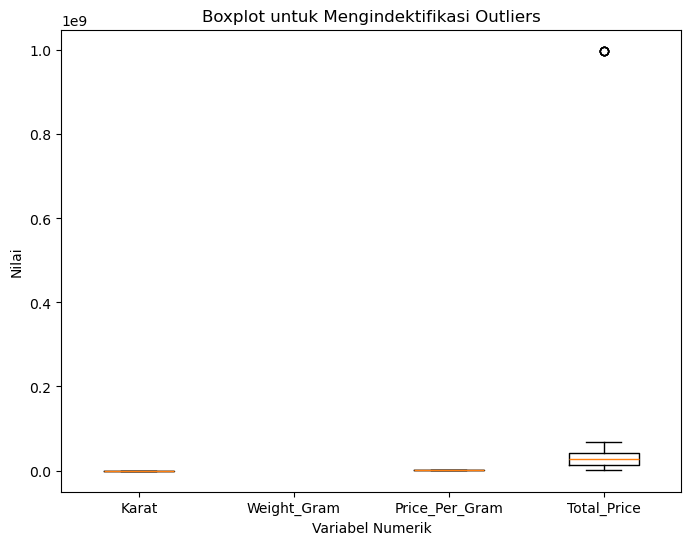

In [61]:
plt.figure(figsize=(8,6))
plt.boxplot(df[colom_numerik],tick_labels=colom_numerik)
plt.title('Boxplot untuk Mengindektifikasi Outliers')
plt.xlabel('Variabel Numerik')
plt.ylabel('Nilai')
plt.show()

### 4.Menggunakan Scatter Plot untuk dua variabel

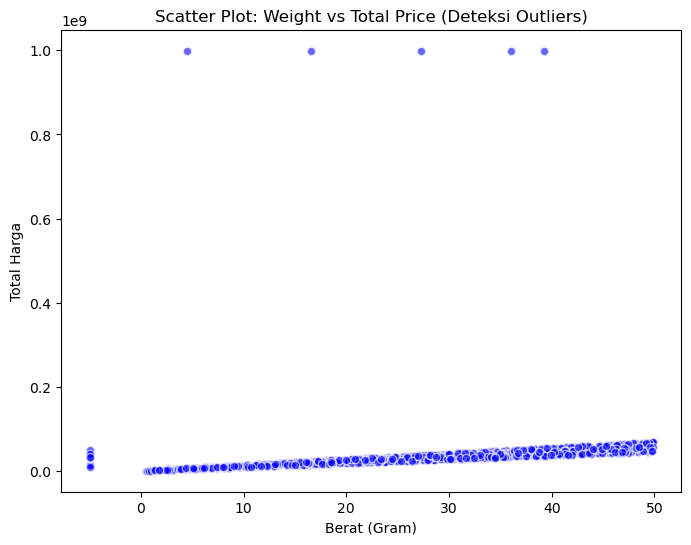

In [62]:
plt.figure(figsize=(8,6))

#Menganalisis outliers hubungan antara dua variabel
plt.scatter(x=df['Weight_Gram'], y=df['Total_Price'], color='blue', alpha=0.6, edgecolors='w')

plt.title('Scatter Plot: Weight vs Total Price (Deteksi Outliers)')
plt.xlabel('Berat (Gram)')
plt.ylabel('Total Harga')
plt.show()

### 5.Menggunakan Local Outlier Factor (LOF) untuk multivariat

In [63]:
from sklearn.neighbors import LocalOutlierFactor
df_target = df.copy()

feature = colom_numerik
df_target= df_target.dropna()

lof = LocalOutlierFactor(n_neighbors=20,contamination=0.01)
df_target['outliers'] = lof.fit_predict(df_target[feature])
outliers = df_target.loc[df_target['outliers'] == -1]

print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')
outliers

Jumlah outliers terdeteksi: 10


,Transaction_ID,Date,Customer_ID,Gold_Type,Karat,Weight_Gram,Price_Per_Gram,Total_Price,Payment_Method,Store_Location,outliers
70,TXN-0813,2024-07-23,CUST-171,Perhiasan,18,4.51,947094,999000000,QRIS,Medan,-1
78,TXN-0365,2024-05-07,CUST-186,Batangan,22,27.28,1120787,999000000,Tunai,Jakarta Pusat,-1
115,TXN-0836,2025-08-26,CUST-372,Perhiasan,24,49.74,1375514,68418066,Kartu Kredit,Makassar,-1
211,TXN-0558,2025-01-31,CUST-404,Batangan,24,16.56,1325603,999000000,Tunai,Bandung,-1
373,TXN-0310,2025-01-26,CUST-119,Batangan,24,49.82,1373775,68441470,QRIS,Medan,-1
534,TXN-0836,2025-08-26,CUST-372,Perhiasan,24,49.74,1375514,68418066,Kartu Kredit,Makassar,-1
600,TXN-0436,2024-02-27,CUST-230,Perhiasan,18,39.28,963705,999000000,QRIS,Bandung,-1
700,TXN-0078,2024-06-10,CUST-353,Perhiasan,18,7.35,948112,6968623,Transfer Bank,Bandung,-1
725,TXN-0409,2025-07-23,CUST-251,Perhiasan,18,7.29,962598,7017339,Kartu Kredit,JKT Pusat,-1
998,TXN-0391,2024-01-20,CUST-391,Batangan,24,36.00,1331772,999000000,QRIS,Makassar,-1


## 2.Penanganan Nilai Outlier

### 1.Menghapus Outlier

In [64]:
df_target = df.copy()
Q1 = df_target[colom_numerik].quantile(0.25)
Q3 = df_target[colom_numerik].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# .all(axis=1) memastikan bahwa SEBUAH BARIS DIPILIH HANYA JIKA SEMUA KOLOM NUMERIKNYA BERADA DI DALAM BATAS AMAN (tidak ada outlier sama sekali).
df_target = df_target.loc[((df_target[colom_numerik] >= lower_bound) & (df_target[colom_numerik] <= upper_bound)).all(axis=1)]

print(f'Jumlah baris sebelum penghapusan: {df.shape[0]}')
print(f'Jumlah baris setelah penghapusan: {df_target.shape[0]}')

Jumlah baris sebelum penghapusan: 1020
Jumlah baris setelah penghapusan: 964


### 2.Mengganti Outlier dengan Nilai Batas

In [65]:
df_target = df.copy()

df_target[colom_numerik] = df_target[colom_numerik].clip(lower=lower_bound,upper=upper_bound,axis=1)

outliers = df_target.loc[((df_target[colom_numerik] < lower_bound) | (df_target[colom_numerik] > upper_bound)).any(axis=1)]
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

Jumlah outliers terdeteksi: 0


### 3.Mengganti Outlier dengan Median

In [66]:
df_target = df.copy()

median = df_target[colom_numerik].median()
kondisi_outliers = (df_target[colom_numerik] < lower_bound) | (df_target[colom_numerik] > upper_bound)
df_target[colom_numerik] = np.where(kondisi_outliers,median,df_target[colom_numerik])

outliers = df_target.loc[((df_target[colom_numerik] < lower_bound) | (df_target[colom_numerik] > upper_bound)).any(axis=1)]
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

Jumlah outliers terdeteksi: 0


### 4.Menggunakan metode Winsorization

In [67]:
from scipy.stats.mstats import winsorize

df_target = df.copy()
df_target[colom_numerik] = df_target[colom_numerik].apply(
    lambda x: winsorize(x,limits=[0.05,0.05])
)

outliers = df_target.loc[((df_target[colom_numerik] < lower_bound) | (df_target[colom_numerik] > upper_bound)).any(axis=1)]
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

Jumlah outliers terdeteksi: 0


### 5.Menggunakan Transformasi Yeo-Johnson

In [83]:
#versi sklearn
from sklearn.preprocessing import PowerTransformer
df_target = df.copy()
df_target[colom_numerik] = df_target[colom_numerik].fillna(0)
pt = PowerTransformer(method='yeo-johnson')
df_target[colom_numerik] = pt.fit_transform(df_target[colom_numerik])

outliers = df_target.loc[((df_target[colom_numerik] < lower_bound) | (df_target[colom_numerik] > upper_bound)).any(axis=1)]
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

Jumlah outliers terdeteksi: 1020


In [84]:
#versi scipy
import pandas as pd
from scipy.stats import yeojohnson

df_target = df.copy()
df_target[colom_numerik] = df_target[colom_numerik].fillna(0)

for col in colom_numerik:
    # [0] digunakan untuk mengambil array datanya saja, mengabaikan nilai lambdanya
    df_target[col] = yeojohnson(df_target[col])[0]

outliers = df_target.loc[((df_target[colom_numerik] < lower_bound) | (df_target[colom_numerik] > upper_bound)).any(axis=1)]
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')


Jumlah outliers terdeteksi: 32
